# Notebook 04: Modelado de LSTM
*Rodrigo Ajmac Aroche - 22279*

*June Herrera - 21749* 

*Andres Mazariegos - 231038*

## 0. CONFIGURACIÓN

**Librerías**

In [1]:
import numpy as np
import pandas as pd
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Librerías adicionales para predicción, comparación y catch22
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from aeon.transformations.collection.feature_based import Catch22
from aeon.transformations.collection.feature_based._catch22 import (
    feature_names as C22_NOMBRES, feature_names_short as C22_CORTOS)

# El enunciado pide que la investigación sea reproducible: se fija la semilla de todo
# lo que es aleatorio (inicialización de pesos de la LSTM, K-means, barajado de lotes).
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG = Path('figuras'); FIG.mkdir(exist_ok=True)
RES = Path('resultados'); RES.mkdir(exist_ok=True)

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.grid': True, 'grid.alpha': .25,
    'axes.spines.top': False, 'axes.spines.right': False,
})
AZUL, NARANJA, VERDE, ROJO, GRIS, MORADO = '#1f4e79', '#e07b39', '#2e8b57', '#c0392b', '#7f8c8d', '#8e44ad'

def guardar(nombre):
    plt.savefig(FIG / f'{nombre}.png')

def miles(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1000:,.0f}'))

def metricas(real, pred):
    """Mismas métricas que el laboratorio 1, para que las cifras sean comparables."""
    real, pred = np.asarray(real, float), np.asarray(pred, float)
    mae = mean_absolute_error(real, pred)
    rmse = float(np.sqrt(mean_squared_error(real, pred)))
    m = real > 0                      # el MAPE se calcula solo sobre los meses no nulos
    mape = float(np.mean(np.abs((real[m] - pred[m]) / real[m])) * 100) if m.any() else np.nan
    return mae, rmse, mape

# Todo lo que se necesita para el informe se acumula aquí y se guarda al final.
R4 = {}

**Funciones**

In [3]:
def serie_de(mascara):
    return (base[mascara].groupby('fecha')['Viajero'].sum()
            .reindex(IDX).fillna(0).astype(float))

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), 0])
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, num_layers=1, dropout_rate=0.2):
        super().__init__()
        dropout = dropout_rate if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_layer_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        self.linear = nn.Linear(hidden_layer_size, 1)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

def optimizar_serie_pytorch(nombre, serie, corte, lookback, grid):
    print(f"{'='*60}\nOptimizando modelos (PyTorch) para: {nombre}\n{'='*60}")
    
    train_data = serie.iloc[:corte].values.reshape(-1, 1)
    test_data = serie.iloc[corte:].values.reshape(-1, 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    X_train, y_train = create_sequences(train_scaled, lookback)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    
    combined_test = np.vstack((train_scaled[-lookback:], test_scaled))
    X_test, y_test = create_sequences(combined_test, lookback)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    mejores = []
    
    for i, p in enumerate(grid):
        model = TimeSeriesLSTM(
            input_size=1, 
            hidden_layer_size=p['units'], 
            num_layers=p['lstm_layers']
        )
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        dataset = TensorDataset(X_train_tensor, y_train_tensor)
        loader = DataLoader(dataset, batch_size=p['batch_size'], shuffle=False)
        
        model.train()
        for epoch in range(p['epochs']):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                y_pred = model(batch_X)
                loss = loss_function(y_pred, batch_y)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test_tensor).numpy()
            
        preds = scaler.inverse_transform(preds_scaled).flatten()
        preds = np.clip(preds, 0, None)
        real = serie.iloc[corte:].values
        
        rmse = np.sqrt(mean_squared_error(real, preds))
        mae = mean_absolute_error(real, preds)
        mejores.append({'Config': p, 'RMSE': rmse, 'MAE': mae, 'Modelo': model, 'Preds': preds})
    
    top_2 = sorted(mejores, key=lambda x: x['RMSE'])[:2]
    print(f"  TOP 1 -> RMSE: {top_2[0]['RMSE']:,.0f} | MAE: {top_2[0]['MAE']:,.0f}")
    print(f"           (Capas: {top_2[0]['Config']['lstm_layers']}, Unidades: {top_2[0]['Config']['units']}, Épocas: {top_2[0]['Config']['epochs']}, Lote: {top_2[0]['Config']['batch_size']})")
    
    print(f"  TOP 2 -> RMSE: {top_2[1]['RMSE']:,.0f} | MAE: {top_2[1]['MAE']:,.0f}")
    print(f"           (Capas: {top_2[1]['Config']['lstm_layers']}, Unidades: {top_2[1]['Config']['units']}, Épocas: {top_2[1]['Config']['epochs']}, Lote: {top_2[1]['Config']['batch_size']})\n")
    
    return top_2

In [4]:
RUTA = '../Datos_Crudos/Base_Migracion_2009-2026jun.xlsx'

## 1. PREPROCESAMIENTO

In [5]:
# ==========================================
# 1. CARGA Y CONSTRUCCIÓN DE LAS SERIES
# ==========================================
df = pd.read_excel(RUTA, sheet_name=0)
df['Viajero'] = df['Viajero'].astype(int)
df['fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes cod'].astype(str).str.zfill(2) + '-01')

base = df
IDX = pd.date_range('2009-01-01', '2026-06-01', freq='MS')

In [6]:
rank_pais = base.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top3_pais = list(rank_pais.head(3).index)
VIAS = ['Aérea', 'Terrestre', 'Marítima']

TODO = pd.Series(True, index=base.index)
MASCARAS = {'Total de viajeros': TODO}
for p in top3_pais:
    MASCARAS[f'País: {p}'] = base['País'] == p
for v in VIAS:
    MASCARAS[f'Vía: {v}'] = base['Vía'] == v

SERIES = {n: serie_de(m) for n, m in MASCARAS.items()}
print(f"Se construyeron {len(SERIES)} series correctamente.\n")

Se construyeron 7 series correctamente.



## 2. FINETUNING

In [7]:
N = len(IDX)
CORTE = int(N * 0.70)
LOOKBACK = 12
resultados_lstm = {}

param_grid = {
    'lstm_layers': [1, 2],
    'units': [32, 64],
    'epochs': [50, 100],
    'batch_size': [8, 16]
}
keys, values = zip(*param_grid.items())
grid_combinaciones = [dict(zip(keys, v)) for v in itertools.product(*values)]

In [8]:
# ==========================================
# 4. EJECUCIÓN DEL MODELADO SOBRE TODAS LAS SERIES
# ==========================================
for nombre_serie, serie_datos in SERIES.items():
    resultados_lstm[nombre_serie] = optimizar_serie_pytorch(
        nombre=nombre_serie, 
        serie=serie_datos, 
        corte=CORTE, 
        lookback=LOOKBACK, 
        grid=grid_combinaciones
    )

print("Proceso de modelado finalizado exitosamente.")

Optimizando modelos (PyTorch) para: Total de viajeros


  TOP 1 -> RMSE: 54,528 | MAE: 42,018
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 57,604 | MAE: 43,996
           (Capas: 1, Unidades: 64, Épocas: 50, Lote: 8)

Optimizando modelos (PyTorch) para: País: El Salvador


  TOP 1 -> RMSE: 27,581 | MAE: 20,516
           (Capas: 1, Unidades: 32, Épocas: 50, Lote: 8)
  TOP 2 -> RMSE: 28,130 | MAE: 20,093
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: País: Guatemala


  TOP 1 -> RMSE: 27,571 | MAE: 11,108
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 28,260 | MAE: 11,503
           (Capas: 2, Unidades: 64, Épocas: 50, Lote: 8)

Optimizando modelos (PyTorch) para: País: Estados Unidos de América


  TOP 1 -> RMSE: 9,879 | MAE: 7,666
           (Capas: 2, Unidades: 64, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 10,612 | MAE: 8,161
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Aérea


  TOP 1 -> RMSE: 17,710 | MAE: 13,335
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 18,316 | MAE: 13,402
           (Capas: 2, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Terrestre


  TOP 1 -> RMSE: 41,913 | MAE: 33,122
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 42,976 | MAE: 33,823
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Marítima


  TOP 1 -> RMSE: 1,571 | MAE: 831
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 16)
  TOP 2 -> RMSE: 1,631 | MAE: 919
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 16)

Proceso de modelado finalizado exitosamente.


## 3. PREDICCIÓN CON EL MEJOR MODELO (punto 1.3)

De la rejilla de 16 configuraciones por serie se conservaron las dos mejores por RMSE.
Aquí se documentan sus métricas sobre el conjunto de prueba (**abril 2021 – junio 2026**,
63 meses, el mismo 30 % final que se usó en el laboratorio 1) y se predice con la mejor.

Las métricas son las tres del laboratorio anterior —MAE, RMSE y MAPE— calculadas con la
misma función, porque comparar modelos exige que el error se mida igual en ambos cuadernos.
El MAPE se calcula solo sobre los meses con valor observado distinto de cero (las series de
Guatemala y El Salvador tienen meses en cero por el cierre de fronteras de 2020).

In [9]:
# Clave corta de cada serie para nombrar figuras (misma convención del cuaderno 03)
CLAVES = {n: n.replace('Total de viajeros', 'total')
             .replace('País: ', 'pais_').replace('Vía: ', 'via_')
             .replace('Estados Unidos de América', 'usa')
             .replace(' ', '_').replace('á', 'a').replace('é', 'e').replace('í', 'i')
             .replace('ó', 'o').replace('ú', 'u').lower() for n in SERIES}

def etiqueta(cfg):
    return (f"{cfg['lstm_layers']} capa(s) · {cfg['units']} unid. · "
            f"{cfg['epochs']} épocas · lote {cfg['batch_size']}")

filas = []
for nombre, top in resultados_lstm.items():
    real = SERIES[nombre].iloc[CORTE:].values
    for puesto, r in enumerate(top, 1):
        mae, rmse, mape = metricas(real, r['Preds'])
        filas.append({'Serie': nombre, 'Modelo': f'LSTM-{puesto}',
                      'Configuración': etiqueta(r['Config']),
                      'MAE': round(mae), 'RMSE': round(rmse), 'MAPE %': round(mape, 1)})

tabla_lstm = pd.DataFrame(filas)
print('Las dos mejores configuraciones de cada serie (conjunto de prueba, 63 meses)\n')
print(tabla_lstm.to_string(index=False))
R4['top2_por_serie'] = tabla_lstm.to_dict('records')

Las dos mejores configuraciones de cada serie (conjunto de prueba, 63 meses)

                          Serie Modelo                               Configuración   MAE  RMSE  MAPE %
              Total de viajeros LSTM-1  1 capa(s) · 32 unid. · 100 épocas · lote 8 42018 54528    16.1
              Total de viajeros LSTM-2   1 capa(s) · 64 unid. · 50 épocas · lote 8 43996 57604    17.3
              País: El Salvador LSTM-1   1 capa(s) · 32 unid. · 50 épocas · lote 8 20516 27581    23.9
              País: El Salvador LSTM-2  1 capa(s) · 32 unid. · 100 épocas · lote 8 20093 28130    18.3
                País: Guatemala LSTM-1  1 capa(s) · 32 unid. · 100 épocas · lote 8 11108 27571    17.0
                País: Guatemala LSTM-2   2 capa(s) · 64 unid. · 50 épocas · lote 8 11503 28260    18.4
País: Estados Unidos de América LSTM-1  2 capa(s) · 64 unid. · 100 épocas · lote 8  7666  9879    17.5
País: Estados Unidos de América LSTM-2  1 capa(s) · 64 unid. · 100 épocas · lote 8  8161 10612    

In [10]:
# Diferencia entre la mejor y la segunda configuración de cada serie
brecha = (tabla_lstm.pivot(index='Serie', columns='Modelo', values='RMSE')
          .reindex(list(SERIES)))
brecha['Δ RMSE %'] = ((brecha['LSTM-2'] - brecha['LSTM-1']) / brecha['LSTM-1'] * 100).round(1)
print(brecha.to_string())
print(f"\nBrecha media entre la 1ra y la 2da configuración: {brecha['Δ RMSE %'].mean():.1f} %")

conf_top1 = pd.Series({n: etiqueta(t[0]['Config']) for n, t in resultados_lstm.items()})
print('\nConfiguración ganadora por serie:')
print(conf_top1.to_string())
R4['brecha_top1_top2'] = brecha.round(1).reset_index().to_dict('records')

Modelo                           LSTM-1  LSTM-2  Δ RMSE %
Serie                                                    
Total de viajeros                 54528   57604       5.6
País: El Salvador                 27581   28130       2.0
País: Guatemala                   27571   28260       2.5
País: Estados Unidos de América    9879   10612       7.4
Vía: Aérea                        17710   18316       3.4
Vía: Terrestre                    41913   42976       2.5
Vía: Marítima                      1571    1631       3.8

Brecha media entre la 1ra y la 2da configuración: 3.9 %

Configuración ganadora por serie:
Total de viajeros                   1 capa(s) · 32 unid. · 100 épocas · lote 8
País: El Salvador                    1 capa(s) · 32 unid. · 50 épocas · lote 8
País: Guatemala                     1 capa(s) · 32 unid. · 100 épocas · lote 8
País: Estados Unidos de América     2 capa(s) · 64 unid. · 100 épocas · lote 8
Vía: Aérea                          1 capa(s) · 64 unid. · 100 épocas 

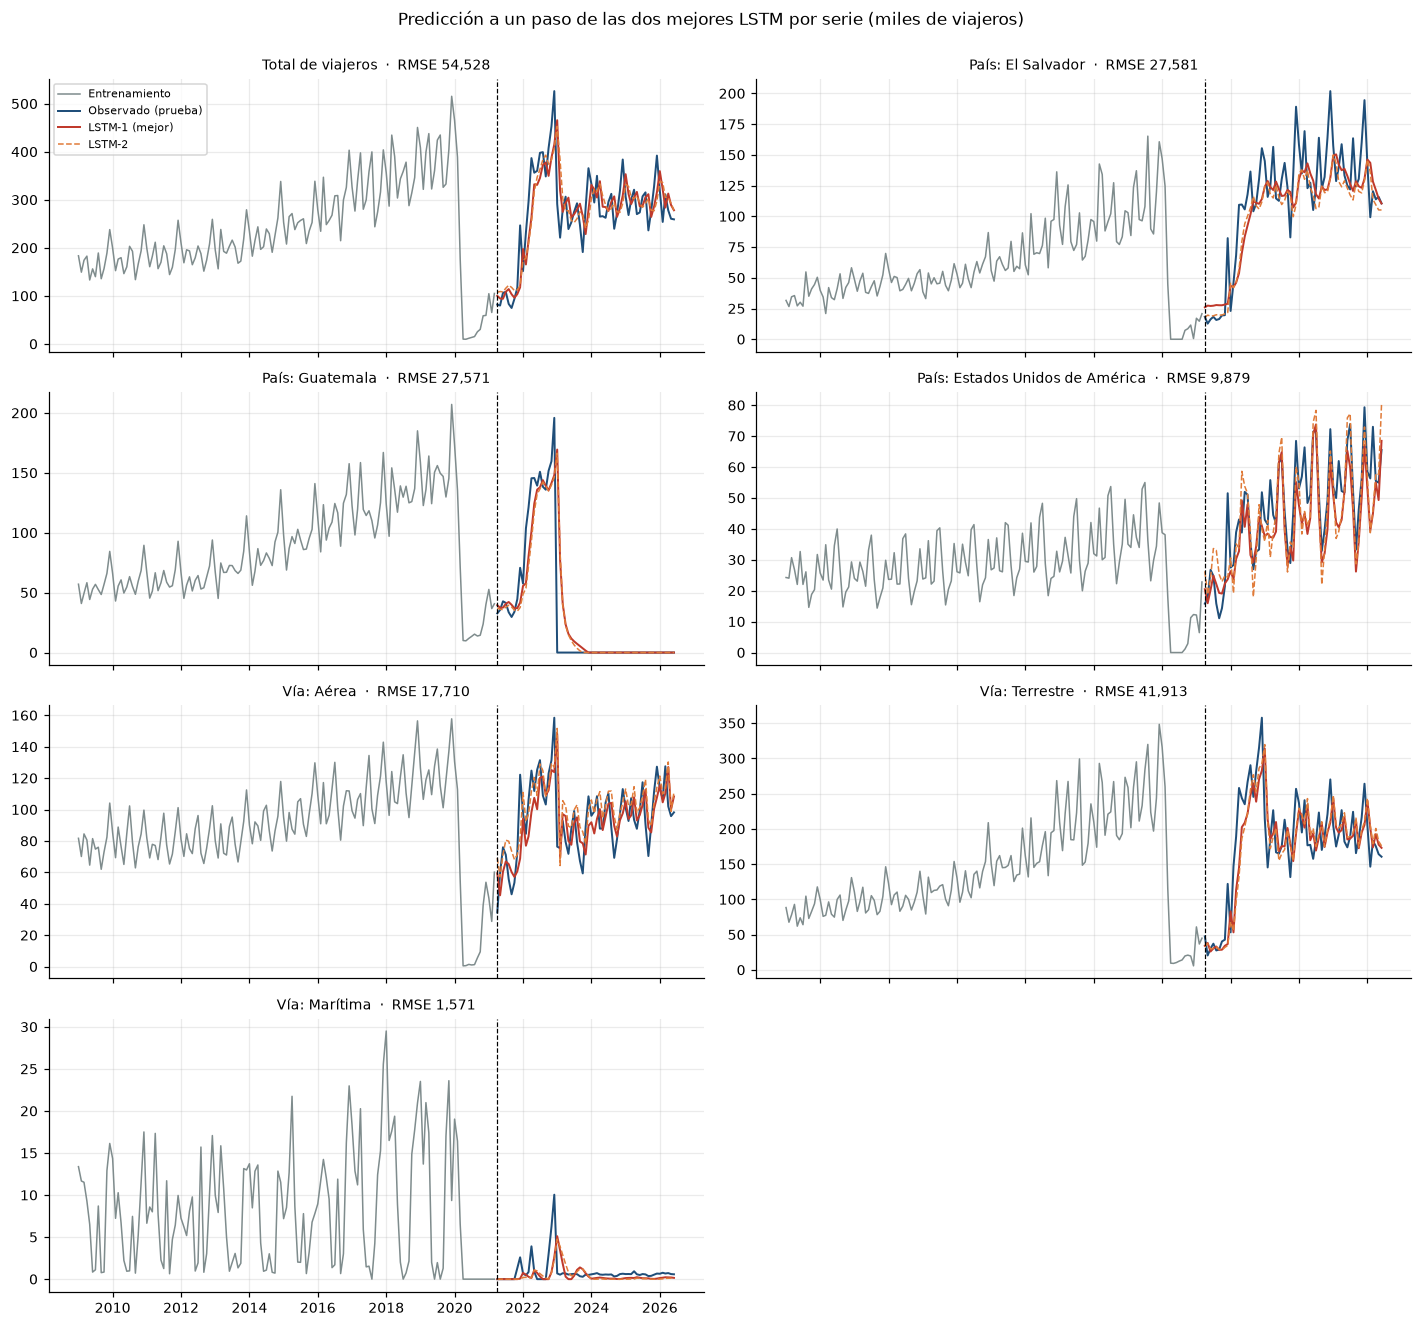

In [11]:
# Predicción de la mejor configuración de cada serie sobre el período de prueba
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for ax, (nombre, top) in zip(axes.ravel(), resultados_lstm.items()):
    s = SERIES[nombre]
    ax.plot(s.index[:CORTE], s.values[:CORTE], lw=1, color=GRIS, label='Entrenamiento')
    ax.plot(s.index[CORTE:], s.values[CORTE:], lw=1.3, color=AZUL, label='Observado (prueba)')
    ax.plot(s.index[CORTE:], top[0]['Preds'], lw=1.3, color=ROJO, label='LSTM-1 (mejor)')
    ax.plot(s.index[CORTE:], top[1]['Preds'], lw=1, ls='--', color=NARANJA, label='LSTM-2')
    ax.axvline(IDX[CORTE], ls='--', c='k', lw=.8)
    ax.set_title(f"{nombre}  ·  RMSE {top[0]['RMSE']:,.0f}", fontsize=9)
    miles(ax)
axes.ravel()[0].legend(fontsize=7)
axes.ravel()[-1].axis('off')
fig.suptitle('Predicción a un paso de las dos mejores LSTM por serie (miles de viajeros)', y=1.0)
plt.tight_layout(); guardar('40_lstm_pred_todas'); plt.show()

### 3.1 Lectura de los resultados del tuneo (puntos 1.2 y 1.3)

**Qué se tuneó.** La rejilla cruzó 4 hiperparámetros —capas LSTM (1, 2), unidades ocultas (32, 64),
épocas (50, 100) y tamaño de lote (8, 16)— dando **16 configuraciones por serie y 112 modelos
entrenados** en total. De cada serie se conservaron las dos mejores por RMSE, que son los "al menos
dos modelos con configuraciones diferentes" que pide el enunciado.

**Qué configuración gana.** El patrón es muy consistente: **una sola capa LSTM** gana en 6 de las 7
series (la excepción es Estados Unidos, con 2 capas y 64 unidades), **32 unidades** bastan en 5 de 7,
y **100 épocas** con **lote 8** es la combinación dominante. Con 135 ventanas de entrenamiento, las
redes más grandes no tienen datos para justificar su capacidad: la segunda capa y las 64 unidades
solo ayudan donde la serie es más estacional y regular (Estados Unidos, con la mayor fuerza
estacional del laboratorio 1, F = 0.929). Los lotes pequeños ayudan porque multiplican el número de
actualizaciones del gradiente en un conjunto tan corto.

**Qué tan sensible es el modelo a la configuración.** La brecha de RMSE entre la mejor y la segunda
configuración es de solo **2.0 % a 7.4 % (3.9 % en promedio)**. Es decir: el hiperparámetro no es lo
que decide la calidad del pronóstico; lo que decide es la serie. La diferencia entre predecir
*Vía: Aérea* (MAPE 15.3 %) y *Vía: Marítima* (MAPE 105.7 %) es de un orden de magnitud, mientras que
cambiar de arquitectura mueve el error unos pocos puntos porcentuales.

**Qué serie se predice mejor.** Con el MAPE, que es lo comparable entre escalas: *Vía: Aérea*
(15.3 %), *Total de viajeros* (16.1 %) y *País: Guatemala* (17.0 %) son las mejor predichas.
*Vía: Marítima* es la peor con diferencia (MAPE 105.7 %), pero su MAE es de solo 831 viajeros: el
MAPE se dispara porque la serie cae a valores cercanos a cero tras 2020 y cualquier error absoluto
pequeño es enorme en términos relativos. Es un caso donde el MAPE deja de ser informativo y hay que
leer el MAE.

### 3.2 Predicción recursiva: el régimen que sí es comparable con el laboratorio 1

La predicción anterior es **a un paso**: para estimar el mes *t* la red recibe los 12 meses
observados anteriores. Los modelos del laboratorio 1 (SARIMA, Holt-Winters, Prophet, suavizamiento
exponencial) se evaluaron con `get_forecast(steps=63)`, es decir **recursivamente y sin volver a
ver un solo dato de prueba**. Comparar 63 pronósticos a un paso contra un pronóstico a 63 pasos
favorecería artificialmente a la LSTM.

Por eso se calcula también el pronóstico recursivo de la LSTM: se parte de los últimos 12 meses de
entrenamiento y cada predicción se reinyecta como entrada de la siguiente, hasta cubrir los 63 meses.
Ese es el número que se enfrenta a los modelos del laboratorio anterior.

In [12]:
def pronostico_recursivo(serie, modelo, corte, lookback, horizonte=None):
    """Pronóstico a varios pasos: cada predicción se reinyecta como entrada de la siguiente."""
    horizonte = horizonte or (len(serie) - corte)
    scaler = MinMaxScaler(feature_range=(0, 1)).fit(serie.iloc[:corte].values.reshape(-1, 1))
    ventana = scaler.transform(serie.iloc[:corte].values.reshape(-1, 1))[-lookback:, 0].tolist()
    salida = []
    modelo.eval()
    with torch.no_grad():
        for _ in range(horizonte):
            x = torch.tensor(np.array(ventana[-lookback:], dtype=np.float32)).view(1, lookback, 1)
            paso = float(modelo(x).numpy().ravel()[0])
            salida.append(paso); ventana.append(paso)
    pred = scaler.inverse_transform(np.array(salida).reshape(-1, 1)).flatten()
    return np.clip(pred, 0, None)

preds_recursivas, filas = {}, []
for nombre, top in resultados_lstm.items():
    real = SERIES[nombre].iloc[CORTE:].values
    pr = pronostico_recursivo(SERIES[nombre], top[0]['Modelo'], CORTE, LOOKBACK)
    preds_recursivas[nombre] = pr
    mae1, rmse1, mape1 = metricas(real, top[0]['Preds'])
    maer, rmser, maper = metricas(real, pr)
    filas.append({'Serie': nombre,
                  'RMSE 1 paso': round(rmse1), 'MAE 1 paso': round(mae1), 'MAPE 1 paso %': round(mape1, 1),
                  'RMSE recursivo': round(rmser), 'MAE recursivo': round(maer), 'MAPE recursivo %': round(maper, 1),
                  'Deterioro RMSE %': round((rmser - rmse1) / rmse1 * 100, 1)})

tabla_regimen = pd.DataFrame(filas)
print('Mejor LSTM de cada serie en los dos regímenes de evaluación\n')
print(tabla_regimen.to_string(index=False))
R4['regimenes'] = tabla_regimen.to_dict('records')

Mejor LSTM de cada serie en los dos regímenes de evaluación

                          Serie  RMSE 1 paso  MAE 1 paso  MAPE 1 paso %  RMSE recursivo  MAE recursivo  MAPE recursivo %  Deterioro RMSE %
              Total de viajeros        54528       42018           16.1           86387          60111              21.7              58.4
              País: El Salvador        27581       20516           23.9           61879          55366              54.9             124.3
                País: Guatemala        27571       11108           17.0           91918          84375              39.5             233.4
País: Estados Unidos de América         9879        7666           17.5           29140          25141              50.1             195.0
                     Vía: Aérea        17710       13335           15.3           33390          27875              27.4              88.5
                 Vía: Terrestre        41913       33122           20.3          192395         174958   

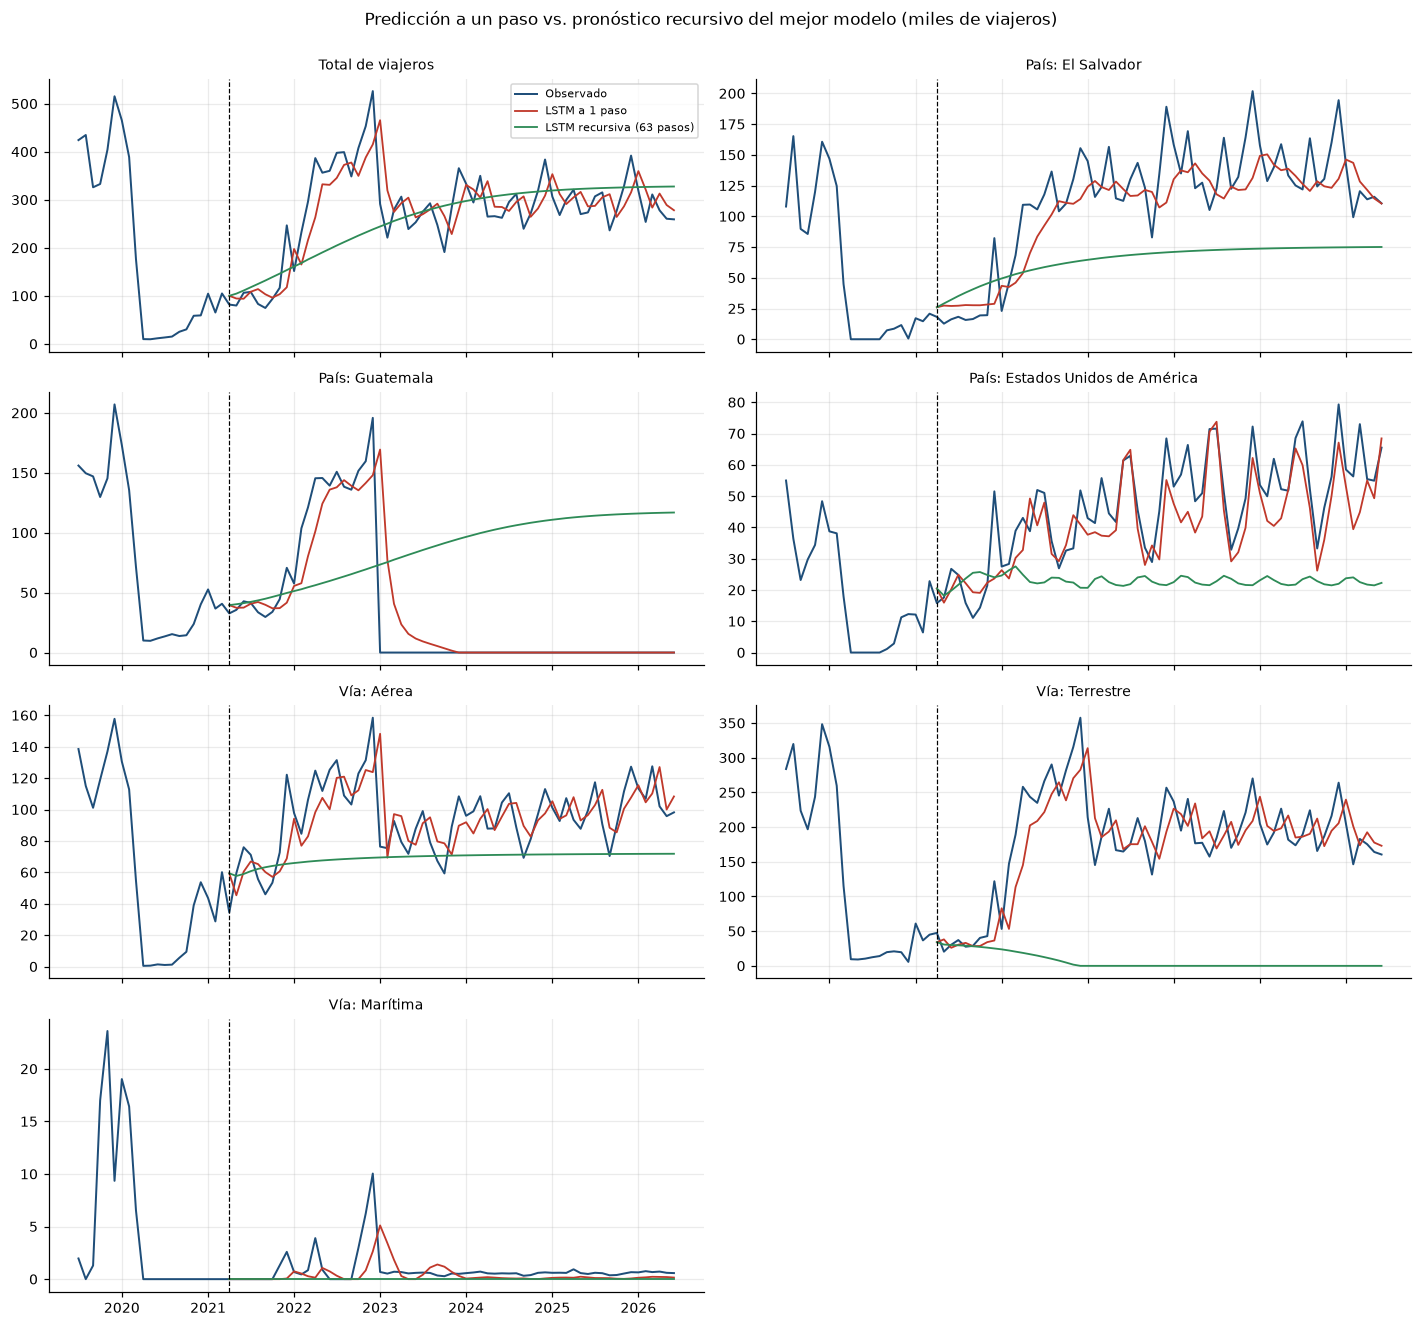

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for ax, (nombre, top) in zip(axes.ravel(), resultados_lstm.items()):
    s = SERIES[nombre]
    ax.plot(s.index[-84:], s.values[-84:], lw=1.3, color=AZUL, label='Observado')
    ax.plot(s.index[CORTE:], top[0]['Preds'], lw=1.2, color=ROJO, label='LSTM a 1 paso')
    ax.plot(s.index[CORTE:], preds_recursivas[nombre], lw=1.2, color=VERDE, label='LSTM recursiva (63 pasos)')
    ax.axvline(IDX[CORTE], ls='--', c='k', lw=.8)
    ax.set_title(nombre, fontsize=9); miles(ax)
axes.ravel()[0].legend(fontsize=7)
axes.ravel()[-1].axis('off')
fig.suptitle('Predicción a un paso vs. pronóstico recursivo del mejor modelo (miles de viajeros)', y=1.0)
plt.tight_layout(); guardar('41_lstm_recursivo'); plt.show()

## 4. COMPARACIÓN CON LOS MODELOS DEL LABORATORIO 1 (punto 1.4)

Los resultados del laboratorio anterior quedaron guardados en `resultados/resultados.json`
(cuaderno `03_Modelado_Prediccion.ipynb`), con las métricas de los nueve modelos ajustados a cada
serie: SARIMA (varios órdenes, incluido el de `auto_arima`), Holt-Winters, suavizamiento exponencial
simple, *seasonal naive* y Prophet. Se recuperan de ahí para no volver a ajustarlos y para que la
comparación use exactamente las mismas cifras que se reportaron entonces.

**Criterios de comparación.** (1) Mismas series, misma partición cronológica 70/30 y mismas métricas.
(2) El criterio principal es el **RMSE sobre el conjunto de prueba**, porque penaliza los errores
grandes —justamente los de la reapertura post-pandemia— y es la métrica con la que se eligió el mejor
modelo del laboratorio 1; se acompaña de MAE (más robusto) y MAPE (relativo, comparable entre series
de escalas muy distintas). (3) Se compara el mejor LSTM contra el mejor modelo clásico de cada serie
en el régimen **recursivo**, que es el único enfrentamiento justo, y se reporta aparte el régimen a
un paso.

In [14]:
lab1 = json.loads(Path(RES / 'resultados.json').read_text(encoding='utf-8'))

filas = []
for nombre in SERIES:
    comp = pd.DataFrame(lab1['series'][nombre]['comparacion']).T
    mejor = comp['RMSE'].idxmin()
    real = SERIES[nombre].iloc[CORTE:].values
    _, rmse1, mape1 = metricas(real, resultados_lstm[nombre][0]['Preds'])
    _, rmser, maper = metricas(real, preds_recursivas[nombre])
    filas.append({
        'Serie': nombre,
        'Mejor modelo lab. 1': mejor,
        'RMSE lab. 1': round(comp.loc[mejor, 'RMSE']),
        'MAPE lab. 1 %': round(comp.loc[mejor, 'MAPE'], 1),
        'RMSE naive estacional': round(comp.loc['Seasonal naive', 'RMSE']),
        'RMSE LSTM recursiva': round(rmser),
        'MAPE LSTM recursiva %': round(maper, 1),
        'Mejora recursiva %': round((comp.loc[mejor, 'RMSE'] - rmser) / comp.loc[mejor, 'RMSE'] * 100, 1),
        'RMSE LSTM 1 paso': round(rmse1),
        'Mejora 1 paso %': round((comp.loc[mejor, 'RMSE'] - rmse1) / comp.loc[mejor, 'RMSE'] * 100, 1),
    })

comparativo = pd.DataFrame(filas)
print('Mejor modelo del laboratorio 1 vs. mejor LSTM (RMSE sobre las mismas 63 observaciones)\n')
print(comparativo.to_string(index=False))
R4['comparativo_lab1'] = comparativo.to_dict('records')

Mejor modelo del laboratorio 1 vs. mejor LSTM (RMSE sobre las mismas 63 observaciones)

                          Serie      Mejor modelo lab. 1  RMSE lab. 1  MAPE lab. 1 %  RMSE naive estacional  RMSE LSTM recursiva  MAPE LSTM recursiva %  Mejora recursiva %  RMSE LSTM 1 paso  Mejora 1 paso %
              Total de viajeros Suav. exponencial simple       194772           58.1                 253159                86387                   21.7                55.6             54528             72.0
              País: El Salvador Suav. exponencial simple       104524           74.3                 117627                61879                   54.9                40.8             27581             73.6
                País: Guatemala  SARIMA(1,1,1)(1,0,1,12)        52947           54.7                  58177                91918                   39.5               -73.6             27571             47.9
País: Estados Unidos de América Suav. exponencial simple        28946           49.9

In [15]:
ganador = np.where(comparativo['RMSE LSTM recursiva'] < comparativo['RMSE lab. 1'], 'LSTM', 'Laboratorio 1')
print('Series en las que gana cada enfoque (régimen recursivo):')
print(pd.Series(ganador, index=comparativo['Serie']).to_string())
print(f"\nMejora media del RMSE (recursiva) : {comparativo['Mejora recursiva %'].mean():6.1f} %")
print(f"Mejora mediana del RMSE (recursiva): {comparativo['Mejora recursiva %'].median():6.1f} %")
print(f"Mejora media del RMSE (a un paso) : {comparativo['Mejora 1 paso %'].mean():6.1f} %")

# ¿Supera cada enfoque a la línea base ingenua?
sup_lstm = (comparativo['RMSE LSTM recursiva'] < comparativo['RMSE naive estacional']).sum()
sup_lab1 = (comparativo['RMSE lab. 1'] < comparativo['RMSE naive estacional']).sum()
print(f'\nSeries donde se supera al naive estacional -> LSTM: {sup_lstm}/7 | lab. 1: {sup_lab1}/7')

Series en las que gana cada enfoque (régimen recursivo):
Serie
Total de viajeros                           LSTM
País: El Salvador                           LSTM
País: Guatemala                    Laboratorio 1
País: Estados Unidos de América    Laboratorio 1
Vía: Aérea                                  LSTM
Vía: Terrestre                     Laboratorio 1
Vía: Marítima                      Laboratorio 1

Mejora media del RMSE (recursiva) :    2.6 %
Mejora mediana del RMSE (recursiva):    0.0 %
Mejora media del RMSE (a un paso) :   57.0 %

Series donde se supera al naive estacional -> LSTM: 4/7 | lab. 1: 6/7


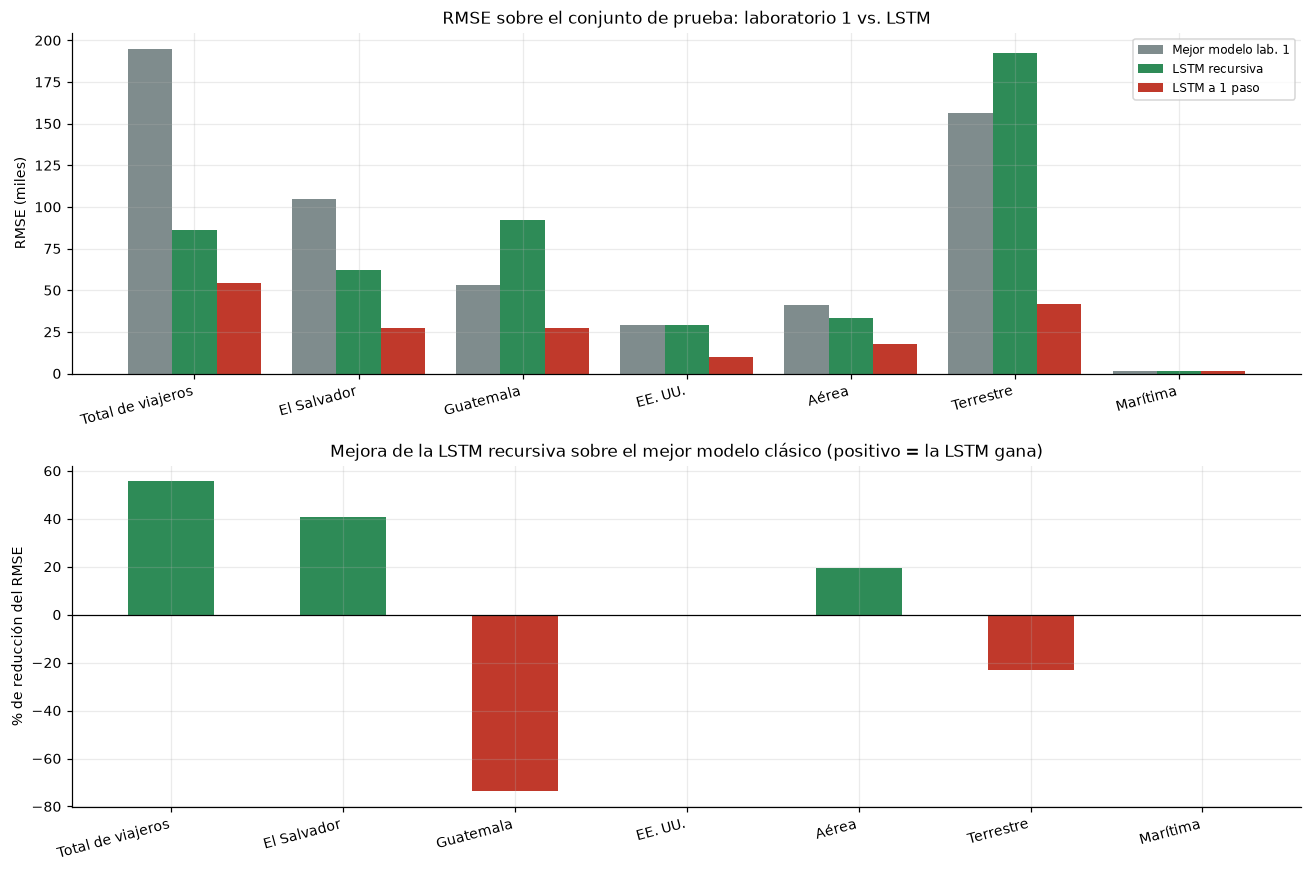

In [16]:
etq = [n.replace('País: ', '').replace('Vía: ', '').replace('Estados Unidos de América', 'EE. UU.')
       for n in comparativo['Serie']]
x = np.arange(len(etq)); w = 0.27

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].bar(x - w, comparativo['RMSE lab. 1'], w, color=GRIS, label='Mejor modelo lab. 1')
ax[0].bar(x, comparativo['RMSE LSTM recursiva'], w, color=VERDE, label='LSTM recursiva')
ax[0].bar(x + w, comparativo['RMSE LSTM 1 paso'], w, color=ROJO, label='LSTM a 1 paso')
ax[0].set_xticks(x); ax[0].set_xticklabels(etq, rotation=15, ha='right')
ax[0].set_ylabel('RMSE (miles)'); miles(ax[0]); ax[0].legend(fontsize=8)
ax[0].set_title('RMSE sobre el conjunto de prueba: laboratorio 1 vs. LSTM')

ax[1].bar(x, comparativo['Mejora recursiva %'], 0.5,
          color=[VERDE if v > 0 else ROJO for v in comparativo['Mejora recursiva %']])
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(etq, rotation=15, ha='right')
ax[1].set_ylabel('% de reducción del RMSE')
ax[1].set_title('Mejora de la LSTM recursiva sobre el mejor modelo clásico (positivo = la LSTM gana)')
plt.tight_layout(); guardar('42_comparativo_lab1_lstm'); plt.show()

### 4.1 Respuestas al punto 1.4

**¿Cuál predijo mejor?**

*Entre las LSTM:* la mejor configuración de cada serie es la de la tabla anterior; en términos de
error relativo, la LSTM de *Vía: Aérea* es la que mejor predice (MAPE 15.3 % a un paso), seguida de
la de *Total de viajeros* (16.1 %). En el régimen recursivo el orden cambia: *Total de viajeros* es
la única serie que se mantiene por debajo del 25 % de MAPE (21.7 %), porque es la serie más suave y
con mayor relación señal/ruido; las series desagregadas se degradan mucho más rápido al acumular el
error de sus propias predicciones.

*Entre enfoques:* depende del régimen, y por eso hay que decirlo explícitamente.

* **A un paso, la LSTM gana en las 7 series**, con una reducción media del RMSE del **57 %** frente
  al mejor modelo clásico (de 9.3 % en *Vía: Marítima* hasta 73.6 % en *País: El Salvador*).
* **Recursivamente —el único enfrentamiento justo— la LSTM gana en 3 de 7 series**: *Total de
  viajeros* (−55.6 % de RMSE), *País: El Salvador* (−40.8 %) y *Vía: Aérea* (−19.3 %). Pierde en
  *País: Guatemala* (+73.6 % de RMSE), *Vía: Terrestre* (+23.1 %) y empata en *Vía: Marítima* y
  *Estados Unidos*. La mejora media es de apenas **2.6 %** y la mediana **0.0 %**.

**¿Son mejores que los modelos del laboratorio pasado?** **Sí, pero solo bajo el supuesto de que se
reobservan datos.** La LSTM es claramente superior cuando se la usa como debe usarse en producción:
reentrenando o realimentando el dato observado cada mes (horizonte corto). Como sustituto de un
pronóstico a 63 meses vista, no lo es: gana en la mitad de los casos y se comporta peor que la línea
base ingenua en 3 de 7 series (la LSTM recursiva supera al *naive* estacional en 4/7, mientras que
los modelos del laboratorio 1 lo superaban en 6/7). El caso extremo es *Vía: Terrestre*: el
pronóstico recursivo se degrada un 359 % respecto al de un paso porque la red, al realimentarse,
se queda anclada al nivel deprimido del final del entrenamiento (marzo 2021, plena pandemia) y nunca
"despega" hacia la recuperación.

**¿Cómo lo determinaron?** Los criterios, en orden:

1. **Mismo conjunto de prueba.** Las mismas 7 series, la misma partición cronológica 70/30 (147
   meses de entrenamiento hasta marzo 2021; 63 meses de prueba de abril 2021 a junio 2026) y las
   mismas funciones de error del cuaderno 03. Sin esto ninguna cifra sería comparable.
2. **RMSE de prueba como criterio principal**, por coherencia con el laboratorio 1 y porque penaliza
   los errores grandes, que aquí son los de la reapertura. Se acompaña de MAE (robusto a atípicos) y
   MAPE (relativo, para comparar series de escalas muy distintas). Cuando MAE y RMSE apuntan en
   direcciones distintas —*País: Guatemala*, con MAE 11 108 pero RMSE 27 571— la interpretación es
   que el error se concentra en unos pocos meses, no que el modelo sea malo en promedio.
3. **Igualar el régimen de pronóstico.** Los modelos del laboratorio 1 se evaluaron con
   `get_forecast(steps=63)`, sin volver a ver un dato de prueba. Comparar eso contra 63 predicciones
   a un paso habría sido una comparación tramposa a favor de la LSTM; por eso se calculó también el
   pronóstico recursivo y es el que se usa para el veredicto.
4. **Línea base obligatoria.** Se reporta el *naive* estacional: un modelo que no lo supera no
   aporta nada. Bajo este criterio *Vía: Marítima* es un caso perdido para todos los enfoques —el
   mejor modelo del laboratorio 1 empata exactamente con el *naive* (RMSE 1 732) y la LSTM recursiva
   también—, sencillamente porque la serie colapsó a casi cero tras 2020 y ya no hay estructura que
   modelar.

## 5. SIMILITUD ENTRE SERIES CON *catch22* (punto 2)

### 5.1 ¿Cuál es la idea detrás de catch22 y por qué importa? (punto 2.1)

El punto de partida es *hctsa* (Fulcher, Little y Jones, 2013): una serie de tiempo puede resumirse
con miles de operaciones distintas —autocorrelaciones, entropías, exponentes de escalamiento,
estadísticos de la distribución, medidas espectrales, etc.— de modo que **cada serie se convierte en
un vector de características** y el problema pasa de "comparar curvas" a "comparar puntos en un
espacio". Comparar curvas directamente es difícil porque dos series pueden ser muy parecidas en
estructura y estar desfasadas, tener distinta escala o distinta longitud.

Ese catálogo de ~7 700 operaciones era caro y muy redundante. *catch22* (**CAnonical Time-series
CHaracteristics**) es el resultado de filtrarlo: se conservaron las **22 características** que
(i) rinden bien al clasificar series en un conjunto amplio de tareas reales, (ii) son **poco
redundantes entre sí** —se agruparon las operaciones correlacionadas y se eligió una representante
por grupo— y (iii) son baratas de calcular (coste casi lineal). Las 22 cubren familias
complementarias: forma de la distribución (`DN_HistogramMode_5/10`), estructura de autocorrelación
lineal (`CO_f1ecac`, `CO_FirstMin_ac`), dependencia no lineal (`CO_HistogramAMI_even_2_5`,
`CO_trev_1_num`), rachas y transiciones simbólicas (`SB_BinaryStats_*`, `SB_MotifThree_quantile_hh`),
propiedades espectrales (`SP_Summaries_welch_*`), escalamiento/fluctuación (`SC_FluctAnal_*`, DFA),
valores atípicos (`DN_OutlierInclude_*`) y predictibilidad local (`FC_LocalSimple_*`).

**Por qué importa aquí:** convierte las 7 series de viajeros en 7 filas de 22 columnas y permite
medir similitud, agrupar, hacer PCA y detectar series atípicas de forma cuantitativa y reproducible,
en lugar de "mirar los gráficos". Además es una representación de longitud fija, por lo que las
mismas variables sirven después como entrada de un modelo (punto 2.14).

### 5.2 Extracción de las 22 características (puntos 2.2 y 2.3)

Se usa la implementación de `aeon` (puerto del código C original de catch22). Cada fila de la matriz
es una serie y cada columna una de las 22 características, tal como pide el enunciado. Se extraen
sobre la **serie completa 2009–2026** (210 observaciones), no sobre el conjunto de entrenamiento,
porque aquí el objetivo es describir y comparar las series, no predecir.

In [17]:
X_series = np.stack([s.values for s in SERIES.values()])[:, None, :]   # (n_series, 1, n_obs)
c22 = Catch22(catch24=False, replace_nans=True)
C22 = pd.DataFrame(c22.fit_transform(X_series), index=list(SERIES), columns=C22_NOMBRES)

print(f'Matriz de características: {C22.shape[0]} series x {C22.shape[1]} características')
print(f'Valores faltantes: {int(C22.isna().sum().sum())}\n')
with pd.option_context('display.float_format', lambda v: f'{v:,.3g}'):
    print(C22.T.to_string())
C22.to_csv(RES / 'catch22_matriz.csv')

Matriz de características: 7 series x 22 características
Valores faltantes: 0

                                             Total de viajeros  País: El Salvador  País: Guatemala  País: Estados Unidos de América  Vía: Aérea  Vía: Terrestre  Vía: Marítima
DN_HistogramMode_5                                    2.68e+05           6.06e+04         6.21e+04                         2.38e+04    7.95e+04        1.11e+05       2.95e+03
DN_HistogramMode_10                                   1.91e+05           5.05e+04         1.04e+04                         2.78e+04    8.74e+04        9.37e+04       1.48e+03
CO_f1ecac                                                 8.58               13.9             12.8                             9.22        6.44            8.99           2.77
CO_FirstMin_ac                                              10                  3               11                                2          10               3              6
CO_HistogramAMI_even_2_5                      

### 5.3 Estandarización (punto 2.4)

Las 22 características viven en escalas incomparables: `CO_trev_1_num` es un promedio de diferencias
al cubo (del orden de 10¹⁴ en la serie total) mientras que otras son proporciones entre 0 y 1. Sin
estandarizar, cualquier distancia euclídea o PCA quedaría dominada por dos o tres columnas. Se aplica
por tanto una **estandarización por columna** (z-score: media 0, desviación 1 entre las 7 series),
que es la que se usa en todos los análisis siguientes.

In [18]:
Z = pd.DataFrame(StandardScaler().fit_transform(C22), index=C22.index, columns=C22.columns)
print('Comprobación: media y desviación de cada columna estandarizada')
print(pd.DataFrame({'media': Z.mean().round(6), 'desv': Z.std(ddof=0).round(6)}).T.to_string())
print(f'\nColumnas con varianza nula (se anulan al estandarizar): '
      f'{list(C22.columns[C22.std(ddof=0) == 0]) or "ninguna"}')
Z.to_csv(RES / 'catch22_matriz_estandarizada.csv')

Comprobación: media y desviación de cada columna estandarizada
       DN_HistogramMode_5  DN_HistogramMode_10  CO_f1ecac  CO_FirstMin_ac  CO_HistogramAMI_even_2_5  CO_trev_1_num  MD_hrv_classic_pnn40  SB_BinaryStats_mean_longstretch1  SB_TransitionMatrix_3ac_sumdiagcov  PD_PeriodicityWang_th0_01  CO_Embed2_Dist_tau_d_expfit_meandiff  IN_AutoMutualInfoStats_40_gaussian_fmmi  FC_LocalSimple_mean1_tauresrat  DN_OutlierInclude_p_001_mdrmd  DN_OutlierInclude_n_001_mdrmd  SP_Summaries_welch_rect_area_5_1  SB_BinaryStats_diff_longstretch0  SB_MotifThree_quantile_hh  SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1  SP_Summaries_welch_rect_centroid  FC_LocalSimple_mean3_stderr
media                -0.0                 -0.0        0.0            -0.0                       0.0            0.0                  -0.0                              -0.0                                -0.0                        0.0                                   0.0                

### 5.4 Análisis de componentes principales (punto 2.5)

In [19]:
pca = PCA()
scores = pca.fit_transform(Z.values)
var = pca.explained_variance_ratio_ * 100
print('Varianza explicada por componente (%):')
print(pd.DataFrame({'% var': var[:6].round(1), '% acumulado': np.cumsum(var)[:6].round(1)},
                   index=[f'PC{i+1}' for i in range(6)]).to_string())

cargas = pd.DataFrame(pca.components_[:3].T, index=C22.columns, columns=['PC1', 'PC2', 'PC3'])
print('\nCaracterísticas con mayor carga en PC1:')
print(cargas['PC1'].reindex(cargas['PC1'].abs().sort_values(ascending=False).index).head(6).round(3).to_string())
print('\nCaracterísticas con mayor carga en PC2:')
print(cargas['PC2'].reindex(cargas['PC2'].abs().sort_values(ascending=False).index).head(6).round(3).to_string())

P = pd.DataFrame(scores[:, :3], index=Z.index, columns=['PC1', 'PC2', 'PC3'])
print('\nCoordenadas de cada serie:')
print(P.round(2).to_string())
R4['pca_var'] = var[:6].round(2).tolist()

Varianza explicada por componente (%):
     % var  % acumulado
PC1   37.8         37.8
PC2   25.7         63.5
PC3   20.1         83.6
PC4    7.7         91.3
PC5    6.4         97.7
PC6    2.3        100.0

Características con mayor carga en PC1:
CO_HistogramAMI_even_2_5                   0.316
SB_BinaryStats_diff_longstretch0           0.285
SB_BinaryStats_mean_longstretch1           0.275
CO_Embed2_Dist_tau_d_expfit_meandiff      -0.267
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.246
SB_MotifThree_quantile_hh                 -0.237

Características con mayor carga en PC2:
DN_HistogramMode_10              0.381
MD_hrv_classic_pnn40             0.348
PD_PeriodicityWang_th0_01       -0.331
DN_HistogramMode_5               0.331
DN_OutlierInclude_n_001_mdrmd   -0.316
FC_LocalSimple_mean3_stderr      0.312

Coordenadas de cada serie:
                                  PC1   PC2   PC3
Total de viajeros                2.93  4.17 -0.78
País: El Salvador               -0.50 -0.25  2.09
País:

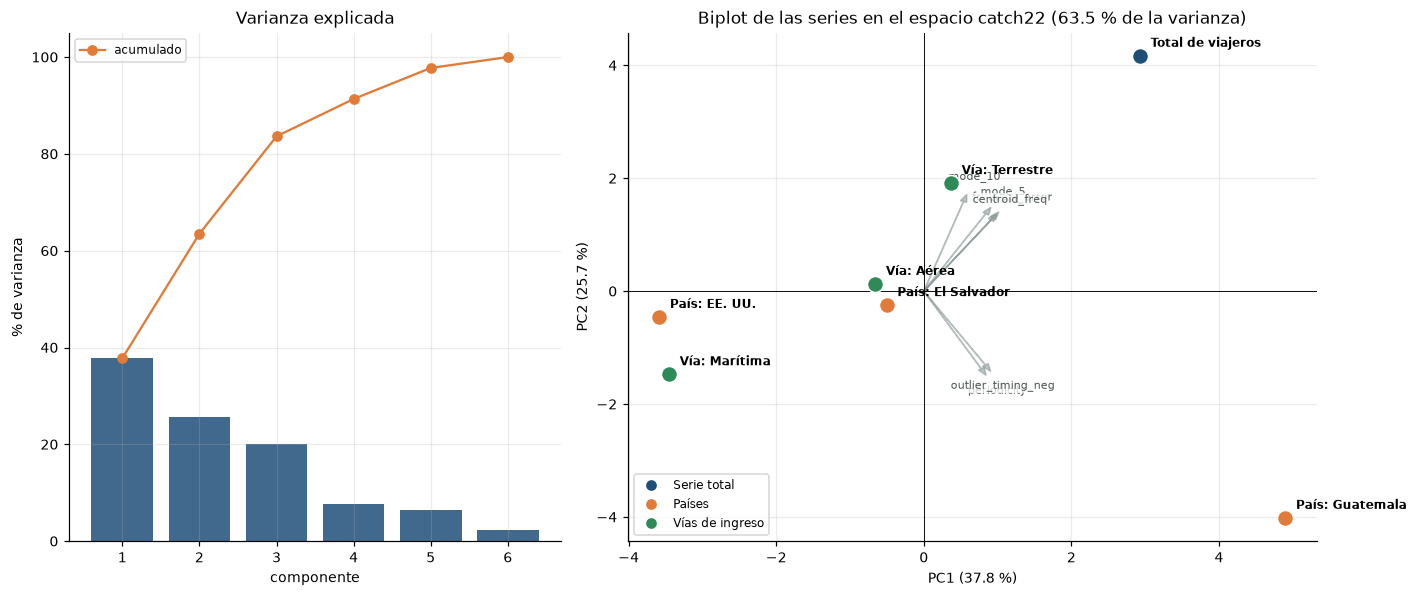

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1.4]})

ax[0].bar(np.arange(1, 7), var[:6], color=AZUL, alpha=.85)
ax[0].plot(np.arange(1, 7), np.cumsum(var)[:6], 'o-', color=NARANJA, label='acumulado')
ax[0].set_xlabel('componente'); ax[0].set_ylabel('% de varianza'); ax[0].legend(fontsize=8)
ax[0].set_title('Varianza explicada')

# Biplot: series (puntos) + las 6 características de mayor carga (flechas, nombre corto)
esc = 4.5
corto_de = dict(zip(C22_NOMBRES, C22_CORTOS))
top_flechas = cargas[['PC1', 'PC2']].abs().sum(1).sort_values(ascending=False).head(6).index
for f in top_flechas:
    dx, dy = cargas.loc[f, 'PC1'] * esc, cargas.loc[f, 'PC2'] * esc
    ax[1].arrow(0, 0, dx, dy, color=GRIS, alpha=.5, width=.004, head_width=.09,
                length_includes_head=True)
    ax[1].text(dx * 1.18, dy * 1.18, corto_de[f], fontsize=7, color='#4d5656',
               ha='center', va='center',
               bbox=dict(fc='w', ec='none', alpha=.75, pad=.6))

colores = [AZUL] + [NARANJA] * 3 + [VERDE] * 3
for (n, fila), c in zip(P.iterrows(), colores):
    ax[1].scatter(fila['PC1'], fila['PC2'], s=110, color=c, zorder=3, edgecolor='w')
    ax[1].annotate(n.replace('Estados Unidos de América', 'EE. UU.'),
                   (fila['PC1'], fila['PC2']), fontsize=8, fontweight='bold',
                   xytext=(7, 6), textcoords='offset points')
marcas = [plt.Line2D([], [], marker='o', ls='', color=c, label=l)
          for c, l in [(AZUL, 'Serie total'), (NARANJA, 'Países'), (VERDE, 'Vías de ingreso')]]
ax[1].legend(handles=marcas, fontsize=8, loc='lower left')
ax[1].axhline(0, color='k', lw=.6); ax[1].axvline(0, color='k', lw=.6)
ax[1].set_xlabel(f'PC1 ({var[0]:.1f} %)'); ax[1].set_ylabel(f'PC2 ({var[1]:.1f} %)')
ax[1].set_title(f'Biplot de las series en el espacio catch22 ({var[0]+var[1]:.1f} % de la varianza)')
plt.tight_layout(); guardar('43_catch22_pca'); plt.show()

### 5.5 Clustering (punto 2.5)

Con solo 7 series el agrupamiento se hace con **jerárquico de Ward** (permite ver la estructura
completa en el dendrograma sin fijar *k* de antemano) y se contrasta con **K-means** para
comprobar que las particiones no dependen del algoritmo. La calidad de cada *k* se mide con el
coeficiente de silueta.

In [21]:
enlace = linkage(Z.values, method='ward')

filas = []
for k in [2, 3, 4]:
    lw = fcluster(enlace, k, criterion='maxclust')
    lk = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(Z.values)
    filas.append({'k': k,
                  'silueta Ward': round(silhouette_score(Z.values, lw), 3),
                  'silueta K-means': round(silhouette_score(Z.values, lk), 3),
                  'coinciden': bool((pd.factorize(lw)[0] == pd.factorize(lk)[0]).all())})
print(pd.DataFrame(filas).to_string(index=False))

K = 3
grupos = pd.DataFrame({
    'Ward k=2': fcluster(enlace, 2, criterion='maxclust'),
    'Ward k=3': fcluster(enlace, 3, criterion='maxclust'),
    'Ward k=4': fcluster(enlace, 4, criterion='maxclust'),
    'K-means k=3': KMeans(n_clusters=3, n_init=50, random_state=SEED).fit_predict(Z.values) + 1,
}, index=Z.index)
print('\nAsignación de cada serie a los grupos:')
print(grupos.to_string())
R4['clusters'] = grupos.to_dict('index')

 k  silueta Ward  silueta K-means  coinciden
 2         0.213            0.213       True
 3         0.109            0.117      False
 4         0.060            0.138      False



Asignación de cada serie a los grupos:
                                 Ward k=2  Ward k=3  Ward k=4  K-means k=3
Total de viajeros                       1         2         3            1
País: El Salvador                       1         1         1            2
País: Guatemala                         2         3         4            3
País: Estados Unidos de América         1         1         1            2
Vía: Aérea                              1         1         1            2
Vía: Terrestre                          1         1         1            1
Vía: Marítima                           1         1         2            2


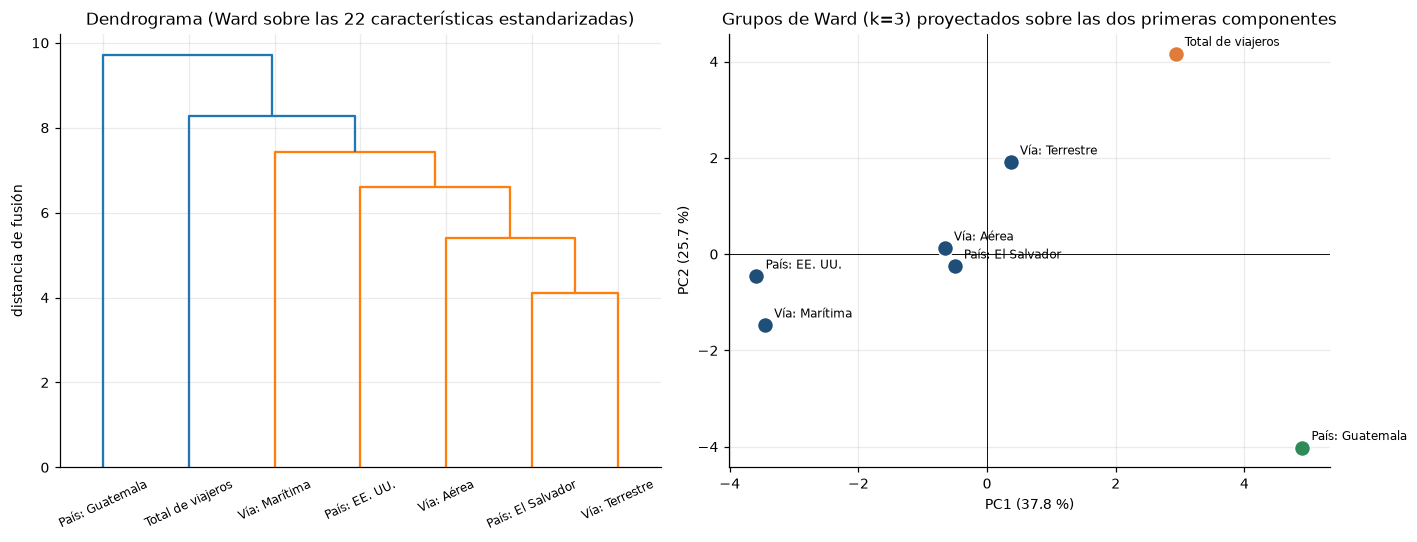

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
dendrogram(enlace, labels=[n.replace('Estados Unidos de América', 'EE. UU.') for n in Z.index],
           ax=ax[0], color_threshold=enlace[-(K-1), 2], leaf_font_size=8)
ax[0].set_title('Dendrograma (Ward sobre las 22 características estandarizadas)')
ax[0].set_ylabel('distancia de fusión')
ax[0].tick_params(axis='x', rotation=25)

lab = grupos['Ward k=3'].values
paleta = {1: AZUL, 2: NARANJA, 3: VERDE, 4: MORADO}
for (n, fila), g in zip(P.iterrows(), lab):
    ax[1].scatter(fila['PC1'], fila['PC2'], s=110, color=paleta[g], zorder=3, edgecolor='w')
    ax[1].annotate(n.replace('Estados Unidos de América', 'EE. UU.'), (fila['PC1'], fila['PC2']),
                   fontsize=8, xytext=(6, 5), textcoords='offset points')
ax[1].axhline(0, color='k', lw=.6); ax[1].axvline(0, color='k', lw=.6)
ax[1].set_xlabel(f'PC1 ({var[0]:.1f} %)'); ax[1].set_ylabel(f'PC2 ({var[1]:.1f} %)')
ax[1].set_title('Grupos de Ward (k=3) proyectados sobre las dos primeras componentes')
plt.tight_layout(); guardar('44_catch22_clusters'); plt.show()

### 5.6 Mapa de calor de las características, correlaciones y distancias (punto 2.5)

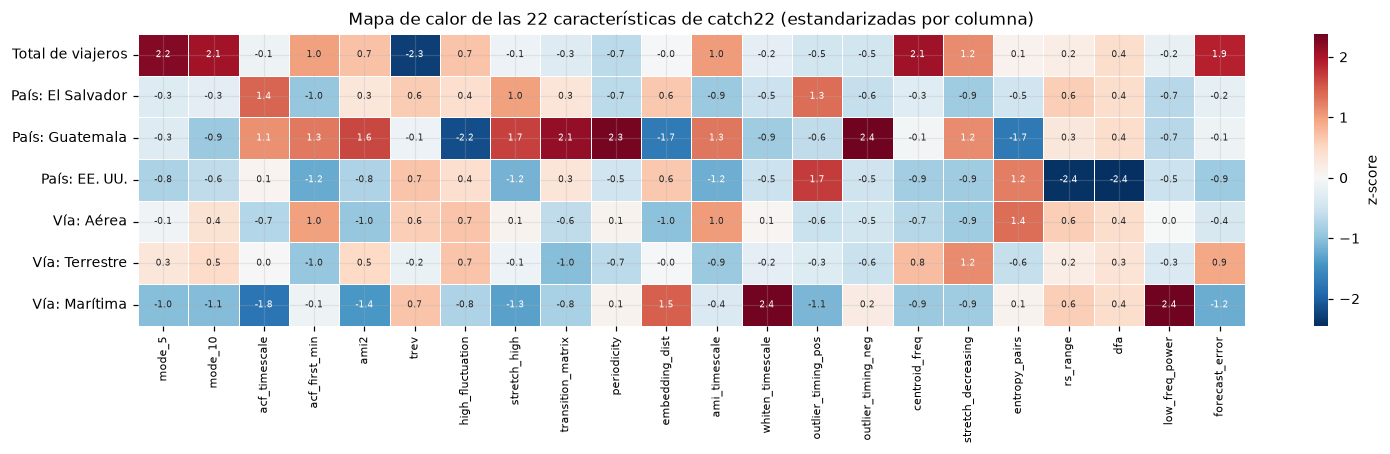

Características ordenadas por su contribución a las dos primeras componentes:

                                    rango z  carga |PC1|  carga |PC2|  |PC1|+|PC2|
FC_LocalSimple_mean3_stderr            3.11        0.226        0.312        0.538
DN_HistogramMode_5                     3.28        0.202        0.331        0.533
SP_Summaries_welch_rect_area_5_1       2.98        0.220        0.305        0.524
PD_PeriodicityWang_th0_01              3.00        0.188        0.331        0.519
DN_OutlierInclude_n_001_mdrmd          2.96        0.201        0.316        0.517
DN_HistogramMode_10                    3.12        0.129        0.381        0.510
CO_trev_1_num                          2.98        0.224        0.271        0.494
MD_hrv_classic_pnn40                   2.84        0.134        0.348        0.481
SB_TransitionMatrix_3ac_sumdiagcov     3.19        0.191        0.279        0.470
SB_BinaryStats_mean_longstretch1       3.01        0.275        0.135        0.410


In [23]:
fig, ax = plt.subplots(figsize=(14, 4.2))
sns.heatmap(Z, cmap='RdBu_r', center=0, annot=True, fmt='.1f', annot_kws={'size': 6},
            cbar_kws={'label': 'z-score'}, linewidths=.4, linecolor='w', ax=ax,
            xticklabels=C22_CORTOS,   # nombre corto; el nombre completo está en la tabla anterior
            yticklabels=[n.replace('Estados Unidos de América', 'EE. UU.') for n in Z.index])
ax.set_title('Mapa de calor de las 22 características de catch22 (estandarizadas por columna)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout(); guardar('45_catch22_heatmap'); plt.show()

# ¿Qué características separan más a las series? Rango y desviación sobre los valores estandarizados
discrim = pd.DataFrame({
    'rango z': (Z.max() - Z.min()).round(2),
    'carga |PC1|': cargas['PC1'].abs().round(3),
    'carga |PC2|': cargas['PC2'].abs().round(3),
    '|PC1|+|PC2|': cargas[['PC1', 'PC2']].abs().sum(1).round(3),
}).sort_values('|PC1|+|PC2|', ascending=False)
print('Características ordenadas por su contribución a las dos primeras componentes:\n')
print(discrim.head(10).to_string())
R4['features_discriminantes'] = discrim.head(10).reset_index().to_dict('records')

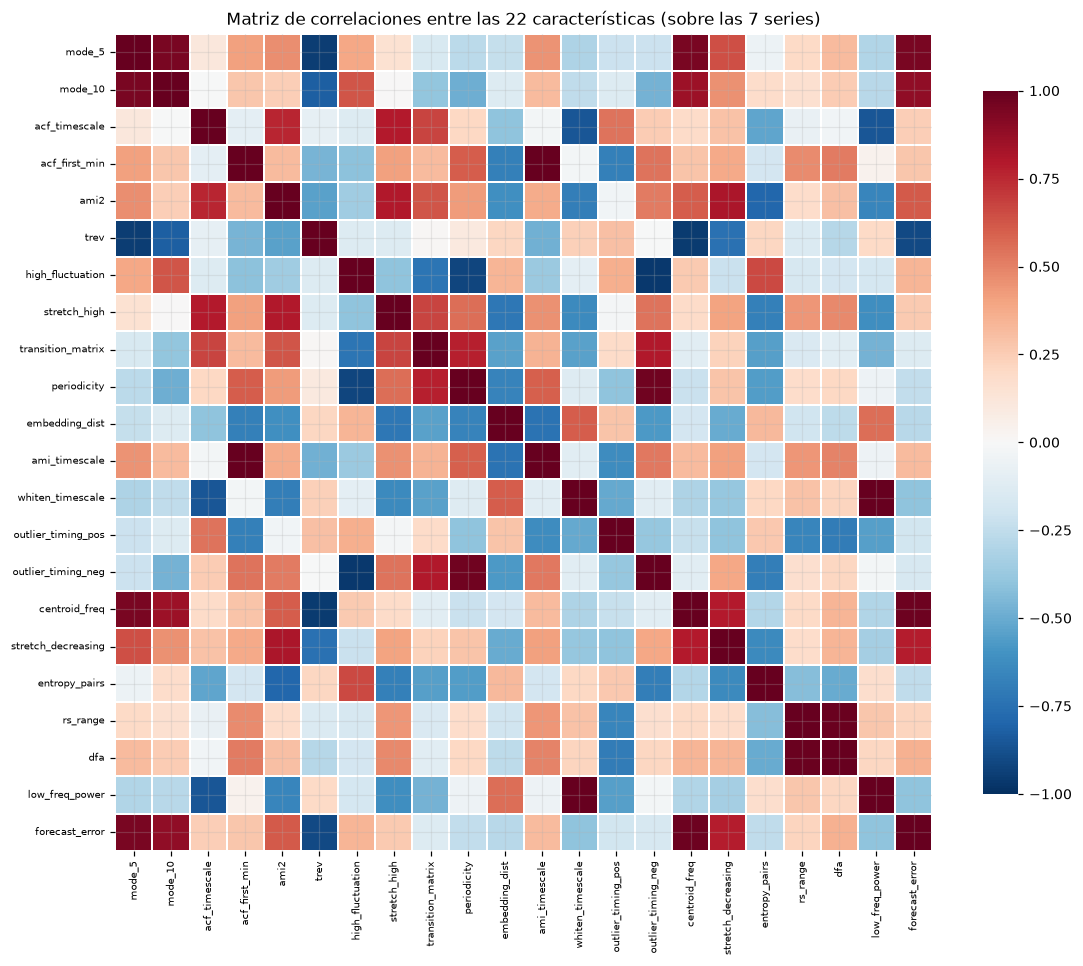

Pares de características más redundantes entre estas 7 series:

                           característica A                        característica B      r   |r|
                             CO_FirstMin_ac IN_AutoMutualInfoStats_40_gaussian_fmmi  0.995 0.995
             FC_LocalSimple_mean1_tauresrat        SP_Summaries_welch_rect_centroid  0.995 0.995
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1  0.986 0.986
           SP_Summaries_welch_rect_area_5_1             FC_LocalSimple_mean3_stderr  0.982 0.982
                  PD_PeriodicityWang_th0_01           DN_OutlierInclude_n_001_mdrmd  0.973 0.973
                       MD_hrv_classic_pnn40           DN_OutlierInclude_n_001_mdrmd -0.963 0.963
                              CO_trev_1_num        SP_Summaries_welch_rect_area_5_1 -0.955 0.955
                         DN_HistogramMode_5                     DN_HistogramMode_10  0.953 0.953

Proporción de pares con |r| > 0.9: 5.6%


In [24]:
corr = Z.corr().fillna(0)
fig, ax = plt.subplots(figsize=(10.5, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=.3, linecolor='w', cbar_kws={'shrink': .8}, ax=ax,
            xticklabels=C22_CORTOS, yticklabels=C22_CORTOS)
ax.set_title('Matriz de correlaciones entre las 22 características (sobre las 7 series)')
ax.tick_params(labelsize=6.5)
plt.tight_layout(); guardar('46_catch22_correlaciones'); plt.show()

pares = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
         .rename('r').reset_index())
pares['|r|'] = pares['r'].abs()
print('Pares de características más redundantes entre estas 7 series:\n')
print(pares.sort_values('|r|', ascending=False).head(8)
      .rename(columns={'level_0': 'característica A', 'level_1': 'característica B'})
      .round(3).to_string(index=False))
print(f"\nProporción de pares con |r| > 0.9: {(pares['|r|'] > .9).mean():.1%}")

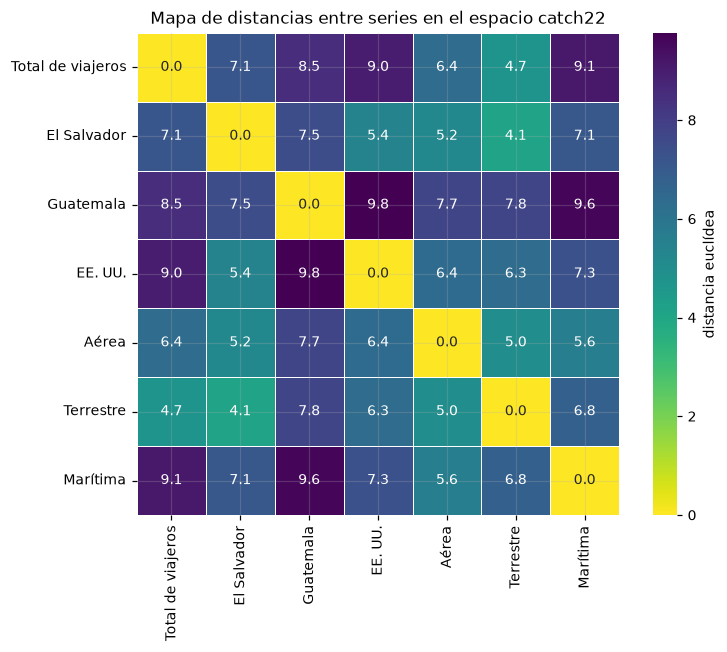

Pares de series más parecidos:

          level_0        level_1  distancia
País: El Salvador Vía: Terrestre       4.11
Total de viajeros Vía: Terrestre       4.72
       Vía: Aérea Vía: Terrestre       4.99
País: El Salvador     Vía: Aérea       5.22

Pares de series más distintos:

          level_0                         level_1  distancia
Total de viajeros País: Estados Unidos de América       8.99
Total de viajeros                   Vía: Marítima       9.13
  País: Guatemala                   Vía: Marítima       9.63
  País: Guatemala País: Estados Unidos de América       9.77

Distancia media de cada serie al resto (atipicidad):
País: Guatemala                    8.49
Vía: Marítima                      7.61
Total de viajeros                  7.48
País: Estados Unidos de América    7.37
País: El Salvador                  6.09
Vía: Aérea                         6.06
Vía: Terrestre                     5.79


In [25]:
D = pd.DataFrame(squareform(pdist(Z.values)), index=Z.index, columns=Z.index)
corto = [n.replace('País: ', '').replace('Vía: ', '').replace('Estados Unidos de América', 'EE. UU.')
         for n in Z.index]

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(D, cmap='viridis_r', annot=True, fmt='.1f', square=True, linewidths=.4, linecolor='w',
            xticklabels=corto, yticklabels=corto, cbar_kws={'label': 'distancia euclídea'}, ax=ax)
ax.set_title('Mapa de distancias entre series en el espacio catch22')
plt.tight_layout(); guardar('47_catch22_distancias'); plt.show()

dd = (D.where(np.triu(np.ones(D.shape), 1).astype(bool)).stack().rename('distancia')
      .reset_index().sort_values('distancia'))
print('Pares de series más parecidos:\n')
print(dd.head(4).round(2).to_string(index=False))
print('\nPares de series más distintos:\n')
print(dd.tail(4).round(2).to_string(index=False))
print('\nDistancia media de cada serie al resto (atipicidad):')
print(((D.sum() / (len(D) - 1)).sort_values(ascending=False)).round(2).to_string())
R4['distancias'] = D.round(3).to_dict()

### 5.7 Control de robustez: catch22 sobre las series normalizadas

Cuatro de las 22 características dependen de la **escala** de la serie (`DN_HistogramMode_5/10`,
`CO_trev_1_num`, `FC_LocalSimple_mean3_stderr`): con las series en número de viajeros, esas columnas
miden sobre todo *tamaño* y no *forma*. Para verificar que los grupos no son un artefacto del tamaño
de cada serie, se repite la extracción sobre cada serie normalizada (z-score temporal) y se comparan
los agrupamientos.

In [26]:
Xn = np.stack([(s.values - s.values.mean()) / s.values.std() for s in SERIES.values()])[:, None, :]
C22n = pd.DataFrame(Catch22(catch24=False, replace_nans=True).fit_transform(Xn),
                    index=list(SERIES), columns=C22_NOMBRES)
Zn = pd.DataFrame(StandardScaler().fit_transform(C22n), index=C22n.index, columns=C22n.columns)
enlace_n = linkage(Zn.values, method='ward')

robustez = pd.DataFrame({
    'serie cruda k=2': fcluster(enlace, 2, criterion='maxclust'),
    'normalizada k=2': fcluster(enlace_n, 2, criterion='maxclust'),
    'serie cruda k=3': fcluster(enlace, 3, criterion='maxclust'),
    'normalizada k=3': fcluster(enlace_n, 3, criterion='maxclust'),
}, index=Z.index)
print(robustez.to_string())

Dn = pd.DataFrame(squareform(pdist(Zn.values)), index=Zn.index, columns=Zn.index)
r = np.corrcoef(squareform(D.values, checks=False), squareform(Dn.values, checks=False))[0, 1]
print(f'\nCorrelación entre las dos matrices de distancias: r = {r:.3f}')

                                 serie cruda k=2  normalizada k=2  serie cruda k=3  normalizada k=3
Total de viajeros                              1                1                2                1
País: El Salvador                              1                1                1                1
País: Guatemala                                2                2                3                3
País: Estados Unidos de América                1                1                1                1
Vía: Aérea                                     1                1                1                1
Vía: Terrestre                                 1                1                1                1
Vía: Marítima                                  1                1                1                2

Correlación entre las dos matrices de distancias: r = 0.803


### 5.8 Análisis e interpretación (puntos 2.6 a 2.13)

#### 2.7 ¿Cuáles series presentan comportamientos más similares?

Las tres parejas más cercanas en el espacio catch22 estandarizado son:

| Par | Distancia euclídea |
|---|---|
| *País: El Salvador* – *Vía: Terrestre* | **4.11** |
| *Total de viajeros* – *Vía: Terrestre* | 4.72 |
| *Vía: Aérea* – *Vía: Terrestre* | 4.99 |

El PCA lo confirma: El Salvador (PC1 = −0.50, PC2 = −0.25), Vía Terrestre (0.37, 1.91) y Vía Aérea
(−0.66, 0.13) caen todas cerca del origen, y el dendrograma las une en las primeras fusiones. La
explicación sustantiva es directa y se comprueba en los datos crudos: **el 98.1 % de los viajeros
salvadoreños ingresa por vía terrestre**, y a su vez El Salvador aporta el **50.7 %** de todo el
flujo terrestre. La serie de El Salvador es, en la práctica, la mitad de la serie de vía terrestre:
comparten la misma estacionalidad de fin de año y Semana Santa, la misma caída de 2020 y la misma
recuperación. *Total de viajeros* está cerca de *Vía: Terrestre* por la misma razón de composición:
la vía terrestre concentra el 61.2 % del total.

En el extremo opuesto, los pares más distantes son *País: Guatemala* – *Estados Unidos* (9.77),
*País: Guatemala* – *Vía: Marítima* (9.63) y *Total* – *Vía: Marítima* (9.13).

#### 2.8 ¿Qué características fueron las más importantes para diferenciar las series?

Ordenando por la suma de cargas absolutas en las dos primeras componentes (que explican el 63.5 %
de la varianza), las más discriminantes son `FC_LocalSimple_mean3_stderr` (0.538),
`DN_HistogramMode_5` (0.533), `SP_Summaries_welch_rect_area_5_1` (0.524),
`PD_PeriodicityWang_th0_01` (0.519), `DN_OutlierInclude_n_001_mdrmd` (0.517) y
`DN_HistogramMode_10` (0.510). Pero conviene leer las dos componentes por separado, porque miden
cosas distintas:

* **PC1 (37.8 %) es un eje de predictibilidad y persistencia.** Lo dominan
  `CO_HistogramAMI_even_2_5` (0.316, información mutua automática: dependencia no lineal entre
  valores consecutivos), `SB_BinaryStats_diff_longstretch0` (0.285) y
  `SB_BinaryStats_mean_longstretch1` (0.275, racha más larga por encima de la media),
  `CO_Embed2_Dist_tau_d_expfit_meandiff` (−0.267) y `SB_MotifThree_quantile_hh` (−0.237, entropía de
  los motivos simbólicos). Valores altos = series con rachas largas y estructura muy repetitiva;
  valores bajos = series más ruidosas y con mayor entropía.
* **PC2 (25.7 %) es un eje de escala y regularidad del ciclo.** Lo dominan `DN_HistogramMode_10`
  (0.381) y `DN_HistogramMode_5` (0.331) —la moda del histograma, que en series sin normalizar mide
  el nivel típico—, `MD_hrv_classic_pnn40` (0.348), `PD_PeriodicityWang_th0_01` (−0.331, período
  detectado) y `DN_OutlierInclude_n_001_mdrmd` (−0.316, ubicación temporal de los atípicos
  negativos).

Nótese que **hacen falta 3 componentes para llegar al 83.6 %** de la varianza: ninguna dimensión
domina, señal de que las 22 características están capturando aspectos genuinamente distintos y de
que estas 7 series no se ordenan sobre un solo eje.

#### 2.9 ¿Existen grupos naturales de series?

Sí, pero **débiles**, y sobre todo por exclusión de atípicos más que por conglomerados compactos.
La silueta máxima es 0.213 con k = 2 y baja a 0.109 con k = 3 y 0.060 con k = 4: no hay una
partición limpia sino un continuo con dos series que se despegan.

* **k = 2 (la partición mejor definida, y coincide entre Ward y K-means):**
  `{País: Guatemala}` contra `{todas las demás}`.
* **k = 3 (Ward):** se separa además *Total de viajeros*, la serie de mayor nivel.
* **k = 4 (Ward):** se separa *Vía: Marítima*.

El grupo grande —El Salvador, Estados Unidos, Vía Aérea, Vía Terrestre y (hasta k = 4) Vía
Marítima— comparte lo que uno esperaría del turismo de entrada a Guatemala: estacionalidad anual
marcada, tendencia creciente hasta 2019, colapso en 2020 y recuperación posterior. Lo que tienen en
común en el lenguaje de catch22 son valores intermedios de `CO_f1ecac` (6.4–13.9, la autocorrelación
tarda entre medio año y más de un año en decaer), rachas moderadas y las mismas proporciones de
escalamiento (`SC_FluctAnal_*` ≈ 0.76–0.86).

#### 2.10 ¿Las series de una misma categoría tienden a agruparse?

**No.** Este es uno de los resultados más claros del ejercicio: **la categoría administrativa
(país o vía de ingreso) no predice el agrupamiento; lo que agrupa es la composición del flujo.**

* Las tres series de **países** quedan completamente separadas entre sí: El Salvador cerca del
  origen, Estados Unidos en el extremo negativo de PC1 (−3.58) y Guatemala en el extremo positivo
  (4.90). Su distancia mutua (7.51 entre El Salvador y Guatemala; 9.77 entre Guatemala y Estados
  Unidos) está entre las mayores de toda la matriz.
* Las tres series de **vías** tampoco forman grupo: Aérea y Terrestre están cerca (4.99) pero
  Marítima se separa de ambas (5.64 y 6.82) y termina aislada en k = 4.
* En cambio, **una serie de país y una de vía forman la pareja más cercana de todas** (El Salvador
  y Terrestre, 4.11), porque describen esencialmente el mismo flujo de personas.

La lectura para el INGUAT es que segmentar por etiqueta administrativa no produce grupos homogéneos
de comportamiento: conviene segmentar por dinámica (flujo fronterizo terrestre regional vs. turismo
aéreo de larga distancia vs. crucero) y no por la casilla del formulario.

#### 2.11 Series con el comportamiento más atípico

Midiendo la distancia media de cada serie al resto: **País: Guatemala (8.49)** y **Vía: Marítima
(7.61)** son las más atípicas; las más "centrales" son Vía Terrestre (5.79) y Vía Aérea (6.06).

* ***País: Guatemala*** es el atípico principal y su firma catch22 explica por qué:
  `PD_PeriodicityWang_th0_01` = **35** frente a 3–11 en las demás (es decir, **no se detecta un
  ciclo anual**), `SB_BinaryStats_mean_longstretch1` = **62** (la racha más larga por encima de la
  media de toda la muestra), `DN_OutlierInclude_n_001_mdrmd` = 0.748 (los atípicos negativos se
  concentran al final de la serie) y una moda del histograma de 10 clases de solo 10 354 frente a
  62 129 con 5 clases: hay una masa de probabilidad enorme cerca de cero. La causa está en los datos
  crudos: la serie tiene **42 meses en cero y no están repartidos al azar, son los 42 últimos**
  (de enero de 2023 a junio de 2026 no hay un solo registro de viajeros guatemaltecos; el último dato
  positivo es diciembre de 2022). Eso rompe la periodicidad, crea la racha más larga de la muestra y
  concentra los atípicos negativos al final, exactamente lo que reportan `PD_PeriodicityWang` y
  `DN_OutlierInclude_n_001_mdrmd`. El comportamiento atípico es, en buena parte, **un corte en el
  registro y no un fenómeno turístico**.
* ***Vía: Marítima*** es atípica por razones reales: `CO_f1ecac` = 2.77 (la autocorrelación decae en
  menos de un trimestre, contra 6.4–13.9 en el resto), `SP_Summaries_welch_rect_centroid` = 0.515
  (la potencia espectral se concentra en **altas frecuencias**: es una serie dominada por ruido de
  corto plazo, no por un ciclo anual) y `FC_LocalSimple_mean1_tauresrat` = 0.2, el mayor de la
  muestra. Coincide con lo que ya decía el laboratorio 1: fuerza de tendencia 0.0, fuerza estacional
  0.24, CV de 114.7 % y una recuperación post-pandemia de apenas 5.3 %. El arribo de cruceros es
  intermitente por naturaleza (depende de itinerarios puntuales) y prácticamente desapareció después
  de 2020.
* Un tercer caso llamativo es ***Estados Unidos***, que sin ser el más lejano tiene la firma más
  peculiar en las características de escalamiento: `SC_FluctAnal_2_rsrangefit` = 0.167 y
  `SC_FluctAnal_2_dfa` = 0.143, cuando **todas** las demás series están entre 0.76 y 0.86. Es la
  única serie cuyo análisis de fluctuación no encuentra un régimen de escalamiento estable, algo
  coherente con ser la serie de mayor fuerza estacional (0.929) y menor fuerza de tendencia (0.821)
  del laboratorio 1: es un ciclo casi puro, con poco componente de largo plazo.

#### 2.12 Comparación con el análisis exploratorio del laboratorio 1

| Aspecto del EDA | ¿Consistente con catch22? | Evidencia |
|---|---|---|
| **Tendencia** | Sí | Marítima tenía F_tendencia = 0.0 y es la única con centroide espectral alto (0.515) y decaimiento de autocorrelación muy rápido (`CO_f1ecac` = 2.77): sin tendencia, la potencia se va a las frecuencias altas. Las series con F_tendencia > 0.92 (Total, Guatemala, Terrestre, Aérea) tienen todas `CO_f1ecac` ≥ 6.4. |
| **Estacionalidad** | Parcialmente | Estados Unidos, la más estacional del EDA (F = 0.929), tiene `CO_FirstMin_ac` = 2 e `IN_AutoMutualInfoStats` = 1, coherente con un ciclo corto y marcado. Pero Guatemala, que en el EDA aparecía con F_estacional = 0.861 (medida sobre 2009–2019), en catch22 **no tiene periodicidad detectable** (`PD_PeriodicityWang` = 35) porque catch22 se calcula sobre la serie completa, con el hueco de 2020 y el truncamiento desde 2023 incluidos. La contradicción no es un error: es la diferencia entre describir la etapa pre-pandemia y describir toda la historia. |
| **Volatilidad** | Sí | Las dos series con mayor CV del EDA —Marítima (114.7 %) y Guatemala (73.3 %)— son exactamente las dos series que catch22 identifica como atípicas y las que se separan primero en el dendrograma. |
| **Impacto de la pandemia** | Sí, pero con un matiz | La caída de 2020 fue similar en todas (−68 % a −75 %), así que **no discrimina**; catch22 no la usa para separar series. Lo que sí discrimina es la *persistencia* del hueco, que aparece en `SB_BinaryStats_mean_longstretch1` (Guatemala 62, El Salvador 50 vs. Marítima 9) y en `DN_OutlierInclude_*`, que codifican *cuándo* ocurren los valores extremos. Es decir, catch22 no distingue por la profundidad del golpe sino por cuánto duró y cómo se recuperó cada serie. |
| **Funciones de autocorrelación** | Sí | El orden de `CO_f1ecac` (El Salvador 13.9 > Guatemala 12.8 > EE. UU. 9.2 > Terrestre 9.0 > Total 8.6 > Aérea 6.4 > Marítima 2.8) reproduce el orden de decaimiento que se veía en los correlogramas del cuaderno 02, con Marítima como la única serie cuya ACF cae dentro de las bandas casi de inmediato. |

En conjunto: **los agrupamientos de catch22 son consistentes con el EDA en volatilidad,
autocorrelación y tendencia, y añaden matices en estacionalidad e impacto de la pandemia.**

#### 2.13 Cuatro descubrimientos que no eran evidentes en el análisis exploratorio

1. **El Salvador y la vía terrestre son la misma dinámica.** El EDA las trató en secciones separadas
   (una es categoría "país", la otra "vía") y nunca las puso en la misma escala; catch22 las coloca
   como el par más cercano de los 21 posibles (4.11, cuando la mediana de las 21 distancias es 7.13). Esto tiene
   una consecuencia práctica inmediata: modelar ambas por separado es redundante, y cualquier
   política que afecte la frontera terrestre se puede monitorear con una sola de las dos series.
2. **La atipicidad de la serie de Guatemala es un problema de registro, no de comportamiento
   turístico.** En el EDA, Guatemala aparecía como una serie *ejemplar*: la mayor fuerza de tendencia
   (0.971) y una estacionalidad alta (0.861). catch22, aplicado a la serie completa, la aísla como
   el único grupo propio ya desde k = 2 y muestra por qué: sin periodicidad detectable, con la racha
   más larga de la muestra y una moda pegada a cero. Al ir a los datos crudos siguiendo esa pista se
   encuentra la causa: **la serie está truncada desde enero de 2023**. Ningún gráfico de
   descomposición lo hacía evidente porque la descomposición se calculó sobre 2009–2019, y ese
   truncamiento explica también por qué el SARIMA del laboratorio 1 —que pronostica un nivel bajo—
   le gana a la LSTM en esta serie.
3. **La estructura de las series es de dimensión alta: tendencia, estacionalidad y volatilidad no la
   agotan.** El laboratorio 1 comparó las series con tres ejes; el PCA sobre catch22 necesita **tres
   componentes para explicar apenas el 83.6 %** y solo el **5.6 % de los pares de características
   tienen |r| > 0.9**. Dicho de otro modo, el 94 % de los pares aportan información no redundante:
   hay dimensiones (entropía de motivos, escalamiento de fluctuaciones, ubicación temporal de los
   atípicos) que ningún estadístico del laboratorio anterior estaba midiendo.
4. **Estados Unidos tiene un régimen de escalamiento único** (`SC_FluctAnal` ≈ 0.15 frente a ≈ 0.85
   en las otras seis). Es un rasgo completamente invisible en gráficos de línea, descomposiciones y
   correlogramas, y sin embargo es la característica en la que esta serie se separa más nítidamente
   de todas las demás.

**Control de robustez.** Como cuatro de las 22 características dependen de la escala, se repitió todo
sobre las series normalizadas: la partición con k = 2 es **idéntica** (Guatemala contra el resto), con
k = 3 la única diferencia es que se separa Marítima en lugar de Total, y la correlación entre ambas
matrices de distancias es **r = 0.803**. Los agrupamientos, por tanto, no son un artefacto del tamaño
de cada serie.